# Day 4 - Fund Performance Analytics

## Objectives

- Compute daily returns
- Calculate CAGR
- Compute Sharpe Ratio
- Compute Sortino Ratio
- Compute Alpha & Beta
- Compute Maximum Drawdown
- Build Fund Scorecard
- Compare funds against benchmark indices

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [2]:
BASE_DIR = Path('..')

nav_df = pd.read_csv(BASE_DIR / 'data/processed/clean_nav_history.csv')
fund_df = pd.read_csv(BASE_DIR / 'data/raw/01_fund_master.csv')
benchmark_df = pd.read_csv(BASE_DIR / 'data/raw/10_benchmark_indices.csv')

In [3]:
nav_df['date'] = pd.to_datetime(nav_df['date'])
benchmark_df['date'] = pd.to_datetime(benchmark_df['date'])

## Daily Returns Calculation

In [4]:
nav_df = nav_df.sort_values(
    ['amfi_code', 'date']
)

nav_df['daily_return'] = (
    nav_df.groupby('amfi_code')['nav']
          .pct_change()
)

nav_df[['amfi_code', 'date', 'nav', 'daily_return']].head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [5]:
nav_df.to_csv(
    BASE_DIR / 'data/processed/returns_computed.csv',
    index=False
)

## CAGR Analysis

In [8]:
def calculate_cagr(group):
   group = group.sort_values('date')

   start_nav = group['nav'].iloc[0]
   end_nav = group['nav'].iloc[-1]
   trading_days = len(group)
   years = trading_days / 252
   cagr = ((end_nav / start_nav) ** (1 / years)) - 1

   return cagr

In [ ]:
cagr_df = (
   nav_df.groupby('amfi_code', group_keys=False)
         .apply(calculate_cagr)
         .reset_index()
)

cagr_df.columns = ['amfi_code', 'cagr']

In [10]:
cagr_df = cagr_df.merge(
    fund_df[['amfi_code', 'scheme_name', 'fund_house']],
    on='amfi_code',
    how='left'
)

In [11]:
cagr_df = cagr_df.sort_values('cagr', ascending=False)
cagr_df.head()

,amfi_code,cagr,scheme_name,fund_house
25,120505,0.216208,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
21,119598,0.213657,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
39,149324,0.212797,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
36,148569,0.210660,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
34,148567,0.204482,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF


In [12]:
cagr_df.to_csv(
    BASE_DIR / 'data/processed/cagr_report.csv',
    index=False
)

In [54]:
cagr_df.describe()

,amfi_code,cagr
count,40.000000,40.000000
mean,120247.000000,0.111691
std,14534.998667,0.067709
min,100016.000000,0.008065
25%,118632.750000,0.046823
50%,119551.500000,0.111752
75%,120842.250000,0.163028
max,149324.000000,0.216208


## Sharpe Ratio

In [ ]:
RISK_FREE_RATE = 0.065

def calculate_sharpe(group):
   returns = group['daily_return'].dropna()
   annual_return = ((1 + returns).prod()) ** (252 / len(returns)) - 1
   annual_volatility = (returns.std() * np.sqrt(252))

   sharpe = (
      annual_return - RISK_FREE_RATE
   ) / annual_volatility

   return sharpe

sharpe_df = (
    nav_df.groupby('amfi_code', group_keys=False)
          .apply(calculate_sharpe)
          .reset_index()
)

sharpe_df.columns = ['amfi_code', 'sharpe_ratio']
sharpe_df = sharpe_df.merge(fund_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
sharpe_df.sort_values('sharpe_ratio', ascending=False).head(10)


,amfi_code,sharpe_ratio,scheme_name
34,148567,1.161096,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.034602,Kotak Flexicap Fund - Regular - Growth
36,148569,0.974332,Mirae Asset Tax Saver Fund - Regular - Growth
25,120505,0.926797,ICICI Pru Midcap Fund - Regular - Growth
19,119551,0.916203,SBI Bluechip Fund - Regular Plan - Growth
38,149323,0.870455,DSP Midcap Fund - Regular - Growth
2,100033,0.837330,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,0.795720,Nippon India Large Cap Fund - Regular - Growth
3,101206,0.746112,ABSL Frontline Equity Fund - Regular - Growth
24,120504,0.743793,ICICI Pru Bluechip Fund - Direct - Growth


In [14]:
sharpe_df.to_csv(
   BASE_DIR / 'data/processed/sharpe_values.csv',
   index=False
)

In [15]:
cagr_df.head()

,amfi_code,cagr,scheme_name,fund_house
25,120505,0.216208,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
21,119598,0.213657,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
39,149324,0.212797,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
36,148569,0.210660,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
34,148567,0.204482,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF


In [16]:
sharpe_df.sort_values('sharpe_ratio', ascending=False).head()

,amfi_code,sharpe_ratio,scheme_name
34,148567,1.161096,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.034602,Kotak Flexicap Fund - Regular - Growth
36,148569,0.974332,Mirae Asset Tax Saver Fund - Regular - Growth
25,120505,0.926797,ICICI Pru Midcap Fund - Regular - Growth
19,119551,0.916203,SBI Bluechip Fund - Regular Plan - Growth


In [55]:
sharpe_df['sharpe_ratio'].describe()

count    40.000000
mean      0.008191
std       1.246209
min      -4.445598
25%      -0.196896
50%       0.382093
75%       0.743276
max       1.161096
Name: sharpe_ratio, dtype: float64

## Sortino Ratio

In [ ]:
def calculate_sortino(group):
   returns = group['daily_return'].dropna()
   annual_return = ((1 + returns).prod()) ** (252 / len(returns)) - 1

   downside_returns = returns[returns < 0]
   downside_std = (downside_returns.std() * np.sqrt(252))

   if downside_std == 0:
      return np.nan

   sortino = (annual_return - RISK_FREE_RATE) / downside_std

   return sortino

sortino_df = (
    nav_df.groupby('amfi_code', group_keys=False)
          .apply(calculate_sortino)
          .reset_index()
)

sortino_df.columns = ['amfi_code', 'sortino_ratio']

sortino_df = sortino_df.merge(
   fund_df[
      ['amfi_code', 'scheme_name']
   ], on='amfi_code', how='left'
)

In [18]:
sortino_df.to_csv(
    BASE_DIR / 'data/processed/sortino_values.csv',
    index=False
)

In [56]:
sortino_df['sortino_ratio'].describe()

count    40.000000
mean     -0.121019
std       2.262484
min      -8.356674
25%      -0.281406
50%       0.557476
75%       1.081686
max       1.620345
Name: sortino_ratio, dtype: float64

## Alpha and Beta Analysis

In [20]:
nifty100 = benchmark_df[benchmark_df['index_name'] == 'NIFTY100'].copy()

nifty100 = nifty100.sort_values('date')
nifty100['benchmark_return'] = (nifty100['close_value'].pct_change())

In [22]:
def calculate_alpha_beta(group):
   merged = pd.merge(
      group[['date', 'daily_return']],
      nifty100[['date', 'benchmark_return']],
      on='date',
      how='inner'
   )

   merged = merged.dropna()

   if len(merged) < 30:
      return pd.Series([np.nan, np.nan])

   regression = linregress(merged['benchmark_return'], merged['daily_return'])

   beta = regression.slope
   alpha = (regression.intercept * 252)

   return pd.Series([alpha, beta])

In [23]:
alpha_beta_df = (nav_df.groupby('amfi_code').apply(calculate_alpha_beta).reset_index())
alpha_beta_df.columns = ['amfi_code', 'alpha', 'beta']

alpha_beta_df = alpha_beta_df.merge(
   fund_df[['amfi_code', 'scheme_name']],
   on='amfi_code',
   how='left'
)

In [24]:
alpha_beta_df.to_csv(
    BASE_DIR / 'data/processed/alpha_beta.csv',
    index=False
)

In [25]:
sortino_df.sort_values('sortino_ratio', ascending=False).head()

,amfi_code,sortino_ratio,scheme_name
34,148567,1.620345,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.585294,Kotak Flexicap Fund - Regular - Growth
36,148569,1.434194,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.374322,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.349230,ICICI Pru Midcap Fund - Regular - Growth


In [26]:
alpha_beta_df.head()

,amfi_code,alpha,beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [57]:
alpha_beta_df[['alpha','beta']].describe()

,alpha,beta
count,40.000000,40.000000
mean,0.159085,-0.001958
std,0.087528,0.035194
min,0.028969,-0.066951
25%,0.068612,-0.023937
50%,0.162326,-0.000067
75%,0.221723,0.017026
max,0.303370,0.103497


## Maximum Drawdown Analysis

In [ ]:
def calculate_max_drawdown(group):
   nav_series = group.sort_values('date')['nav']
   running_max = nav_series.cummax()

   drawdowwn = (nav_series / running_max) - 1

   return drawdowwn.min()

max_dd_df = (
   nav_df.groupby('amfi_code')
         .apply(calculate_max_drawdown)
         .reset_index()
)

max_dd_df.columns = ['amfi_code', 'max_drawdown']

max_dd_df = max_dd_df.merge(
   fund_df[['amfi_code', 'scheme_name']],
   on='amfi_code',
   how='left'
)

In [28]:
max_dd_df.to_csv(
   BASE_DIR / 'data/processed/max_drawdown.csv',
   index=False
)

## Fund Scorecard

In [29]:
scorecard_df = cagr_df.merge(sharpe_df[['amfi_code', 'sharpe_ratio']], on='amfi_code')
scorecard_df = scorecard_df.merge(alpha_beta_df[['amfi_code', 'alpha']], on='amfi_code')
scorecard_df = scorecard_df.merge(max_dd_df[['amfi_code', 'max_drawdown']], on='amfi_code')
scorecard_df = scorecard_df.merge(fund_df[['amfi_code', 'expense_ratio_pct']], on='amfi_code')

In [30]:
scorecard_df['return_rank'] = (scorecard_df['cagr'].rank(ascending=False))
scorecard_df['sharpe_rank'] = ( scorecard_df['sharpe_ratio'].rank(ascending=False))
scorecard_df['alpha_rank'] = (scorecard_df['alpha'].rank(ascending=False))

scorecard_df['expense_rank'] = (scorecard_df['expense_ratio_pct'].rank(ascending=True))
scorecard_df['drawdown_rank'] = (scorecard_df['max_drawdown'].rank(ascending=False))

In [31]:
scorecard_df['fund_score'] = (
   scorecard_df['return_rank'] * 0.30 +
   scorecard_df['sharpe_rank'] * 0.25 +
   scorecard_df['alpha_rank'] * 0.20 +
   scorecard_df['expense_rank'] * 0.15 +
   scorecard_df['drawdown_rank'] * 0.10
)

scorecard_df['fund_score'] = (
   100 * (scorecard_df['fund_score'].max() - scorecard_df['fund_score'])
   /
   (scorecard_df['fund_score'].max() - scorecard_df['fund_score'].min())
)

scorecard_df = scorecard_df.sort_values('fund_score', ascending=False)
scorecard_df.head(10)

,amfi_code,cagr,scheme_name,fund_house,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,120505,0.216208,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,0.926797,0.292636,-0.181885,1.36,1.0,4.0,3.0,15.0,25.0,100.000000
4,148567,0.204482,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.161096,0.269838,-0.112657,1.46,5.0,1.0,7.0,23.0,8.0,97.409326
5,120843,0.204060,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,1.034602,0.273305,-0.129740,1.45,6.0,2.0,5.0,22.0,13.0,95.682211
6,100033,0.199081,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,0.837330,0.271954,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0,89.810017
3,148569,0.210660,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,0.974332,0.282704,-0.163967,1.60,4.0,3.0,4.0,36.5,21.0,87.305699
1,119598,0.213657,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,0.699495,0.303370,-0.287060,1.43,2.0,13.0,1.0,21.0,36.0,85.664940
2,149324,0.212797,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,0.703850,0.300579,-0.311719,1.52,3.0,12.0,2.0,26.5,37.0,81.606218
12,120504,0.155335,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,0.743793,0.211948,-0.125883,0.80,13.0,10.0,13.0,12.0,12.0,81.519862
9,119551,0.171499,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,0.916203,0.232010,-0.150124,1.54,10.0,5.0,10.0,30.5,17.0,79.706390
8,119094,0.186926,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,0.743104,0.260767,-0.209609,1.38,9.0,11.0,9.0,17.0,28.0,79.447323


In [32]:
scorecard_df.to_csv(
   BASE_DIR / 'data/processed/fund_scorecard.csv',
   index=False
)

In [33]:
max_dd_df.head()

,amfi_code,max_drawdown,scheme_name
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth


In [34]:
scorecard_df.head(10)

,amfi_code,cagr,scheme_name,fund_house,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,120505,0.216208,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,0.926797,0.292636,-0.181885,1.36,1.0,4.0,3.0,15.0,25.0,100.000000
4,148567,0.204482,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.161096,0.269838,-0.112657,1.46,5.0,1.0,7.0,23.0,8.0,97.409326
5,120843,0.204060,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,1.034602,0.273305,-0.129740,1.45,6.0,2.0,5.0,22.0,13.0,95.682211
6,100033,0.199081,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,0.837330,0.271954,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0,89.810017
3,148569,0.210660,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,0.974332,0.282704,-0.163967,1.60,4.0,3.0,4.0,36.5,21.0,87.305699
1,119598,0.213657,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,0.699495,0.303370,-0.287060,1.43,2.0,13.0,1.0,21.0,36.0,85.664940
2,149324,0.212797,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,0.703850,0.300579,-0.311719,1.52,3.0,12.0,2.0,26.5,37.0,81.606218
12,120504,0.155335,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,0.743793,0.211948,-0.125883,0.80,13.0,10.0,13.0,12.0,12.0,81.519862
9,119551,0.171499,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,0.916203,0.232010,-0.150124,1.54,10.0,5.0,10.0,30.5,17.0,79.706390
8,119094,0.186926,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,0.743104,0.260767,-0.209609,1.38,9.0,11.0,9.0,17.0,28.0,79.447323


In [35]:
scorecard_df[['scheme_name', 'fund_score']].head()

,scheme_name,fund_score
0,ICICI Pru Midcap Fund - Regular - Growth,100.000000
4,Mirae Asset Large Cap Fund - Regular - Growth,97.409326
5,Kotak Flexicap Fund - Regular - Growth,95.682211
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,89.810017
3,Mirae Asset Tax Saver Fund - Regular - Growth,87.305699


In [36]:
output_dir = (BASE_DIR / 'reports/performance_charts')
output_dir.mkdir(parents=True, exist_ok=True)

In [37]:
top5_codes = (scorecard_df.head(5)['amfi_code'].tolist())
top5_nav = nav_df[nav_df['amfi_code'].isin(top5_codes)].copy()

nifty50 = benchmark_df[benchmark_df['index_name'] == 'NIFTY50'].copy()
nifty50['indexed_value'] = (nifty50['close_value'] / nifty50['close_value'].iloc[0] * 100)

nifty100_chart = benchmark_df[benchmark_df['index_name'] == 'NIFTY100'].copy()
nifty100_chart['indexed_value'] = (nifty100_chart['close_value'] / nifty100_chart['close_value'].iloc[0] * 100)

In [42]:
top5_nav['indexed_nav'] = (
   top5_nav.groupby('amfi_code')['nav']
         .transform(
            lambda x: x / x.iloc[0] * 100
         )
)

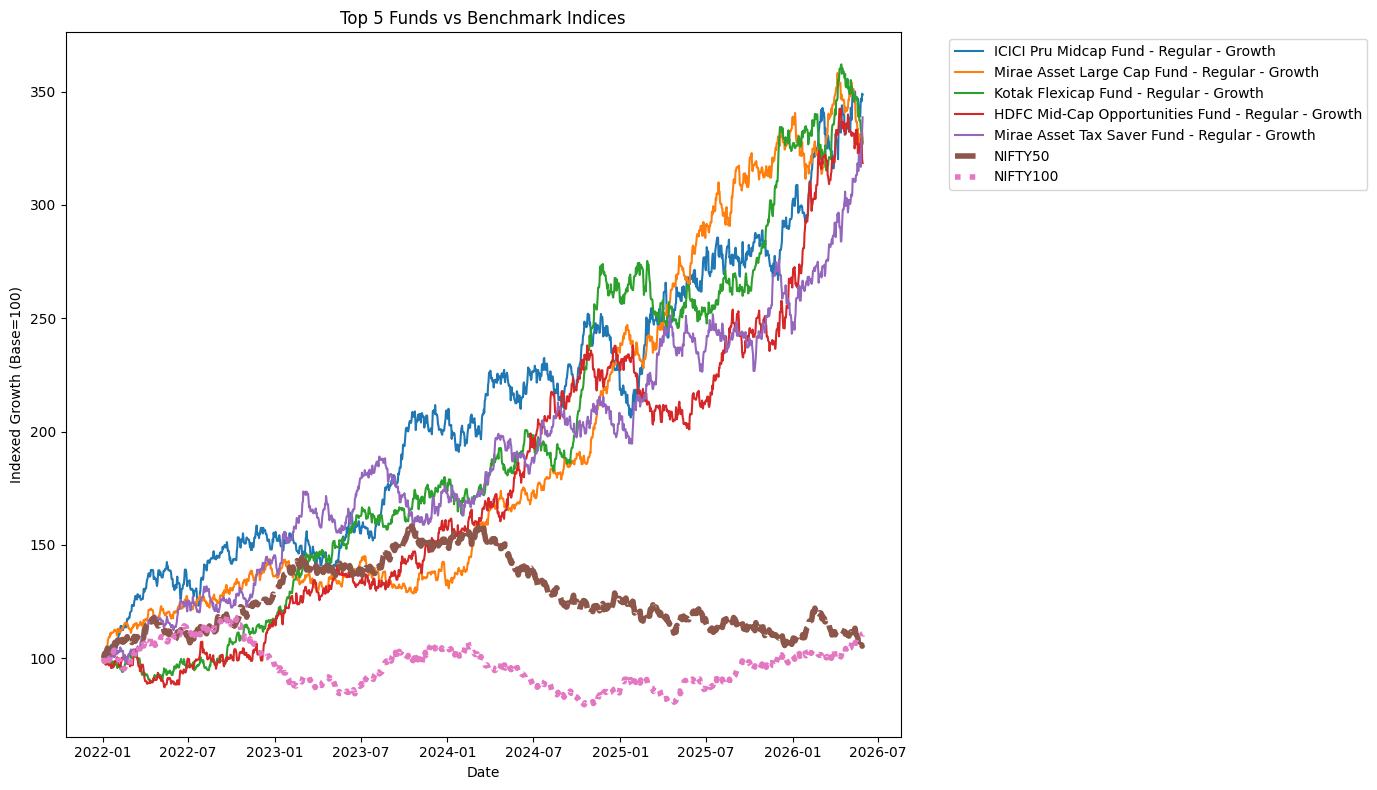

In [ ]:
plt.figure(figsize=(14, 8))
for code in top5_codes:
   fund_data = top5_nav[top5_nav['amfi_code'] == code]

   fund_name = (
      scorecard_df.loc[
         scorecard_df['amfi_code'] == code,
         'scheme_name'
      ].iloc[0]
   )

   plt.plot(
      fund_data['date'],
      fund_data['indexed_nav'],
      label=fund_name
   )

plt.plot(
    nifty50['date'],
    nifty50['indexed_value'],
    linewidth=4,
    linestyle='--',
    label='NIFTY50'
)

plt.plot(
    nifty100_chart['date'],
    nifty100_chart['indexed_value'],
    linewidth=4,
    linestyle=':',
    label='NIFTY100'
)

plt.title(
    'Top 5 Ranked Funds vs NIFTY50 and NIFTY100 (Indexed Base = 100)'
)

plt.xlabel('Date')
plt.ylabel('Indexed Growth (Base=100)')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
   output_dir /
   'benchmark_comparison.png',
   dpi=300,
   bbox_inches='tight'
)

plt.show()

In [58]:
scorecard_df[
   [
      'scheme_name',
      'fund_score',
      'cagr',
      'sharpe_ratio',
      'alpha'
   ]
].head(10)

,scheme_name,fund_score,cagr,sharpe_ratio,alpha
0,ICICI Pru Midcap Fund - Regular - Growth,100.000000,0.216208,0.926797,0.292636
4,Mirae Asset Large Cap Fund - Regular - Growth,97.409326,0.204482,1.161096,0.269838
5,Kotak Flexicap Fund - Regular - Growth,95.682211,0.204060,1.034602,0.273305
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,89.810017,0.199081,0.837330,0.271954
3,Mirae Asset Tax Saver Fund - Regular - Growth,87.305699,0.210660,0.974332,0.282704
1,SBI Small Cap Fund - Regular Plan - Growth,85.664940,0.213657,0.699495,0.303370
2,DSP Small Cap Fund - Regular - Growth,81.606218,0.212797,0.703850,0.300579
12,ICICI Pru Bluechip Fund - Direct - Growth,81.519862,0.155335,0.743793,0.211948
9,SBI Bluechip Fund - Regular Plan - Growth,79.706390,0.171499,0.916203,0.232010
8,Axis Midcap Fund - Regular - Growth,79.447323,0.186926,0.743104,0.260767


### Composite Scoring Methodology

The score combines:

- CAGR (30%)
- Sharpe Ratio (25%)
- Alpha (20%)
- Expense Ratio (15%)
- Maximum Drawdown (10%)

Scores are normalized to a 0–100 scale where higher values indicate better overall performance.

## Key Findings

1. ICICI Pru Midcap Fund achieved the highest overall composite score.

2. Mirae Asset Large Cap Fund delivered the strongest risk-adjusted performance.

3. Midcap and Flexicap funds dominated the top rankings.

4. Multiple funds generated positive alpha relative to NIFTY100.

5. Small-cap oriented schemes experienced larger drawdowns.

6. Sharpe and Sortino ratios provided stronger ranking signals than CAGR alone.

7. Expense ratios influenced final rankings through the composite score.

8. Top-ranked schemes significantly outperformed benchmark indices.

9. Maximum drawdown varied substantially across categories.

10. The composite scorecard successfully differentiated strong and weak performers.